In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error
import yfinance as yf
from math import sqrt

""Data Collection""

In [2]:
data = yf.download(tickers = 'AAPL', start='2002-01-01', end='2024-12-31')
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2002-01-02,0.349069,0.349069,0.328994,0.330342,529496800
2002-01-03,0.353264,0.355811,0.341129,0.344574,612007200
2002-01-04,0.354912,0.358807,0.344425,0.349668,409976000
2002-01-07,0.343077,0.359556,0.340829,0.355361,444584000
2002-01-08,0.338732,0.345324,0.336484,0.340829,450038400


In [3]:
data.shape

(5788, 5)

""Data Preprocessing""

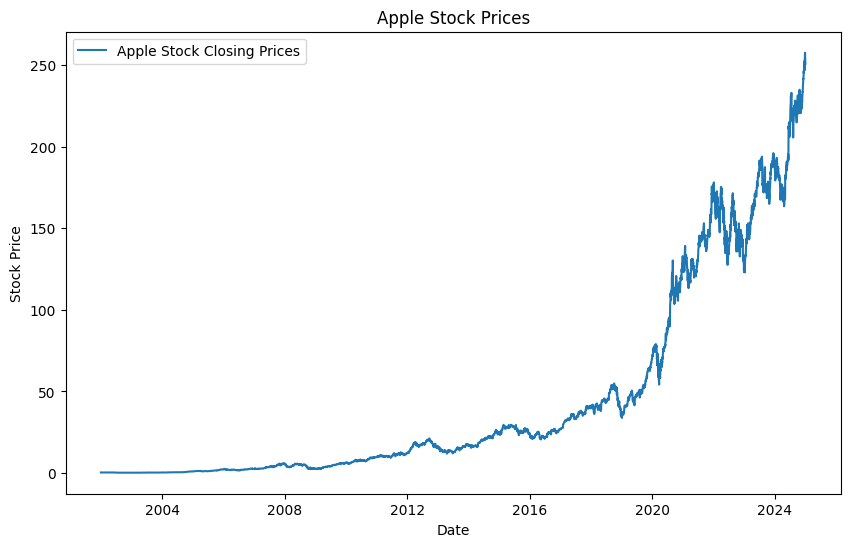

In [4]:
# Visualize the closing prices
plt.figure(figsize=(10, 6))
plt.plot(data['Close'], label='Apple Stock Closing Prices')
plt.title('Apple Stock Prices')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

In [5]:
# Selecting the 'Close' prices for the model
df = data[['Close']]

# Normalize the dataset to scale values between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

# Split the data into training and test sets (80% training, 20% testing)
training_data_len = int(np.ceil(len(scaled_data) * 0.8))
train_data = scaled_data[0:training_data_len]

test_data = scaled_data[training_data_len - 60:]

# Create the training dataset
X_train, y_train = [], []
for i in range(60, len(train_data)):
    X_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Create the testing dataset
X_test, y_test = [], df[training_data_len:].values
for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

""LSTM Model""

In [6]:

# Building the LSTM model
model = Sequential()

# Adding the first LSTM layer
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

# Adding a second LSTM layer
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Adding the output layer
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics = ["mse"])
model.summary()



C:\Users\mayas\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

""Training the Model""

In [8]:
# Training the model
history = model.fit(X_train, y_train, batch_size=32, epochs=100, validation_split=0.1, callbacks=[early_stop])

Epoch 1/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 1.8696e-04 - mse: 1.8696e-04 - val_loss: 1.2166e-04 - val_mse: 1.2166e-04
Epoch 2/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 4.1071e-05 - mse: 4.1071e-05 - val_loss: 1.4165e-04 - val_mse: 1.4165e-04
Epoch 3/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 2.9094e-05 - mse: 2.9094e-05 - val_loss: 1.3939e-04 - val_mse: 1.3939e-04
Epoch 4/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 3.4217e-05 - mse: 3.4217e-05 - val_loss: 1.6271e-04 - val_mse: 1.6271e-04
Epoch 5/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - loss: 2.8434e-05 - mse: 2.8434e-05 - val_loss: 1.0590e-04 - val_mse: 1.0590e-04
Epoch 6/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 9s 68ms/step - loss: 2.6807e-05 - mse: 2.6807e-05 - val_loss: 1.0600e-04 - val_mse: 1.0600e-04
Epoch 7/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - loss: 2.2448e-05 - mse: 2.2448e-05 - val_loss: 9.5229e-05 - val_mse: 9.5229e-05
Epoch 8/100
129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 8

""Model Evaluation and Predictions""

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step


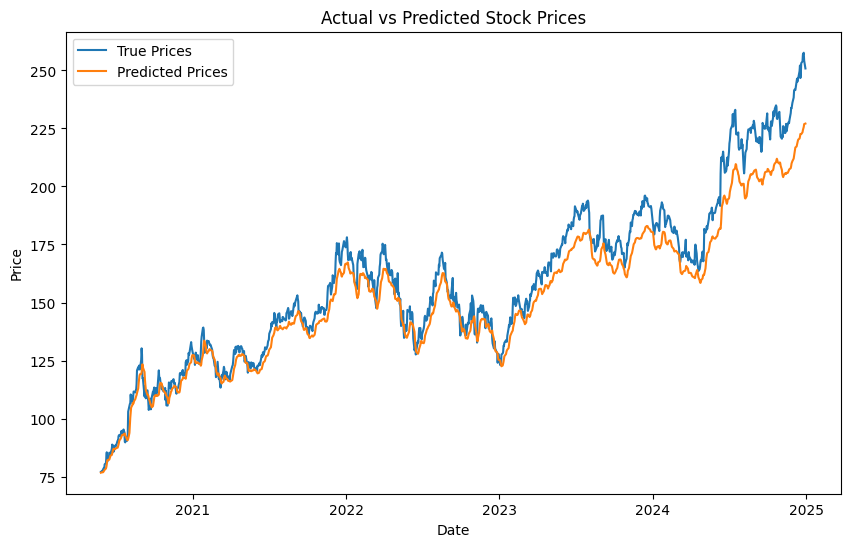

Root Mean Squared Error: 9.849303949652176


In [9]:
# Make predictions
predicted_prices = model.predict(X_test)
predicted_prices = scaler.inverse_transform(predicted_prices)

# Plot predictions vs actual
plt.figure(figsize=(10,6))
plt.plot(df[training_data_len:], label='True Prices')
plt.plot(pd.DataFrame(predicted_prices, index=df[training_data_len:].index), label='Predicted Prices')
plt.title('Actual vs Predicted Stock Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# Calculate RMSE
rmse = sqrt(mean_squared_error(y_test, predicted_prices))
print(f'Root Mean Squared Error: {rmse}')

""Future Price Prediction""

In [10]:
# Use the last 60 days to predict future stock prices
last_60_days = test_data[-60:]
X_predict = last_60_days.reshape(1, last_60_days.shape[0], 1)
predicted_price = model.predict(X_predict)
predicted_price = scaler.inverse_transform(predicted_price)
print(f'Predicted Stock Price for the next day: {predicted_price[0][0]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Predicted Stock Price for the next day: 226.3099365234375


In [11]:
y_test.shape

(1157, 1)

In [12]:
predicted_price.shape

(1, 1)

In [13]:
predicted_prices = model.predict(X_test)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [14]:
predicted_price.shape

(1, 1)

In [15]:
from sklearn.metrics import r2_score

predicted_stock_price = model.predict(X_test)
r2 = r2_score(y_test, predicted_stock_price)

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [16]:
r2 

-19.455575085050995

In [17]:
model.save("lstm_model.h5")


In [18]:
np.save("X_test.npy", X_test)
np.save("y_test.npy", y_test)

In [19]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [20]:
# ASCII diagram of LSTM stock prediction
ascii_diagram = """
Stock Price Prediction with LSTM
---------------------------------
Input: Last 60 Days Closing Prices
Day1   Day2   Day3   ...   Day58   Day59   Day60
  |      |      |             |       |       |
  v      v      v             v       v       v
+---------------------------------------------+
|                  LSTM Cell                  |
|  +-----------+  +-----------+  +---------+ |
|  | Forget    |  | Input     |  | Output  | |
|  | Gate      |  | Gate      |  | Gate    | |
|  +-----------+  +-----------+  +---------+ |
|        \         /             /           |
|         \       /             /            |
|          \     /             /             |
|        Cell State (memory across 60 steps) |
+---------------------------------------------+
                     |
                     v
         Predicted Next Day Price
           (scalar output)
"""

# Show diagram in notebook
print(ascii_diagram)


Stock Price Prediction with LSTM
---------------------------------
Input: Last 60 Days Closing Prices
Day1   Day2   Day3   ...   Day58   Day59   Day60
  |      |      |             |       |       |
  v      v      v             v       v       v
+---------------------------------------------+
|                  LSTM Cell                  |
|  +-----------+  +-----------+  +---------+ |
|  | Forget    |  | Input     |  | Output  | |
|  | Gate      |  | Gate      |  | Gate    | |
|  +-----------+  +-----------+  +---------+ |
|        \         /             /           |
|         \       /             /            |
|          \     /             /             |
|        Cell State (memory across 60 steps) |
+---------------------------------------------+
                     |
                     v
         Predicted Next Day Price
           (scalar output)



<>:2: SyntaxWarning: invalid escape sequence '\ '
<>:2: SyntaxWarning: invalid escape sequence '\ '
C:\Users\mayas\AppData\Local\Temp\ipykernel_5424\1474710836.py:2: SyntaxWarning: invalid escape sequence '\ '
  ascii_diagram = """
